In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
def load_yfinance_csv(path, asset_name):
    df = pd.read_csv(path)
    df = df.iloc[2:].copy()
    df.rename(columns={"Price": "Date"}, inplace=True)

    df = df[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])

    df[asset_name] = pd.to_numeric(df["Close"], errors="coerce")
    df = df[["Date", asset_name]].dropna()

    return df


In [14]:
# Load and merge V and MA prices
v = load_yfinance_csv("V_daily.csv", "V")
ma = load_yfinance_csv("MA_daily.csv", "MA")

df = pd.merge(v, ma, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

df


,Date,V,MA
0,2008-03-19,14.125000,20.839001
1,2008-03-20,16.087500,22.038000
2,2008-03-24,14.932500,21.650000
3,2008-03-25,15.812500,22.497999
4,2008-03-26,15.990000,22.285000
...,...,...,...
4560,2026-05-05,322.029999,497.079987
4561,2026-05-06,318.799988,491.890015
4562,2026-05-07,321.279999,500.940002
4563,2026-05-08,318.790009,495.480011


In [15]:
# Compute returns and log prices
df["V"] = pd.to_numeric(df["V"], errors="coerce")
df["MA"] = pd.to_numeric(df["MA"], errors="coerce")

df = df.dropna(subset=["V", "MA"])
df = df[(df["V"] > 0) & (df["MA"] > 0)].copy()
df = df.sort_values("Date").reset_index(drop=True)

df["V_ret"] = df["V"].pct_change()
df["MA_ret"] = df["MA"].pct_change()

df["log_V"] = np.log(df["V"])
df["log_MA"] = np.log(df["MA"])


In [16]:
# Rolling beta, spread, and z-score
lookback = 252
entry_z = 1.6
exit_z = 0.5

df["beta"] = np.nan
df["spread"] = np.nan
df["zscore"] = np.nan

for i in range(lookback, len(df)):
    train = df.iloc[i - lookback:i]

    x = train["log_V"].values
    y = train["log_MA"].values

    beta = np.polyfit(x, y, 1)[0]
    df.loc[i, "beta"] = beta

    train_spread = train["log_MA"] - beta * train["log_V"]
    mu = train_spread.mean()
    sigma = train_spread.std()

    current_spread = df.loc[i, "log_MA"] - beta * df.loc[i, "log_V"]

    df.loc[i, "spread"] = current_spread
    df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma


In [17]:
# Trading position
df["position"] = 0.0
current_pos = 0

for i in range(lookback, len(df)):
    z = df.loc[i, "zscore"]

    if current_pos == 0:
        if z > entry_z:
            current_pos = -1  # short spread: short MA, long V
        elif z < -entry_z:
            current_pos = 1  # long spread: long MA, short V

    elif current_pos == 1:
        if z > -exit_z:
            current_pos = 0

    elif current_pos == -1:
        if z < exit_z:
            current_pos = 0

    df.loc[i, "position"] = current_pos


In [18]:
# Strategy returns
df["beta_ffill"] = df["beta"].ffill()

# spread = log(MA) - beta * log(V)
# so spread_ret approx = MA_ret - beta * V_ret
df["spread_ret"] = df["MA_ret"] - df["beta_ffill"] * df["V_ret"]

# Lag position so we only earn returns from positions entered previously
df["position_lag"] = df["position"].shift(1).fillna(0)

df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
df["strategy_ret"] = df["strategy_ret"].fillna(0)

df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()


In [19]:
# Strategy metrics
mean_ret = df["strategy_ret"].mean()
std_ret = df["strategy_ret"].std()

sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
total_return = df["equity_curve"].iloc[-1] - 1

rolling_max = df["equity_curve"].cummax()
drawdown = df["equity_curve"] / rolling_max - 1
max_drawdown = drawdown.min()

print("Sharpe Ratio:", sharpe)
print("Total Return:", total_return)
print("Max Drawdown:", max_drawdown)


Sharpe Ratio: 0.6441629304567822
Total Return: 1.9101501817811037
Max Drawdown: -0.26204218775955235


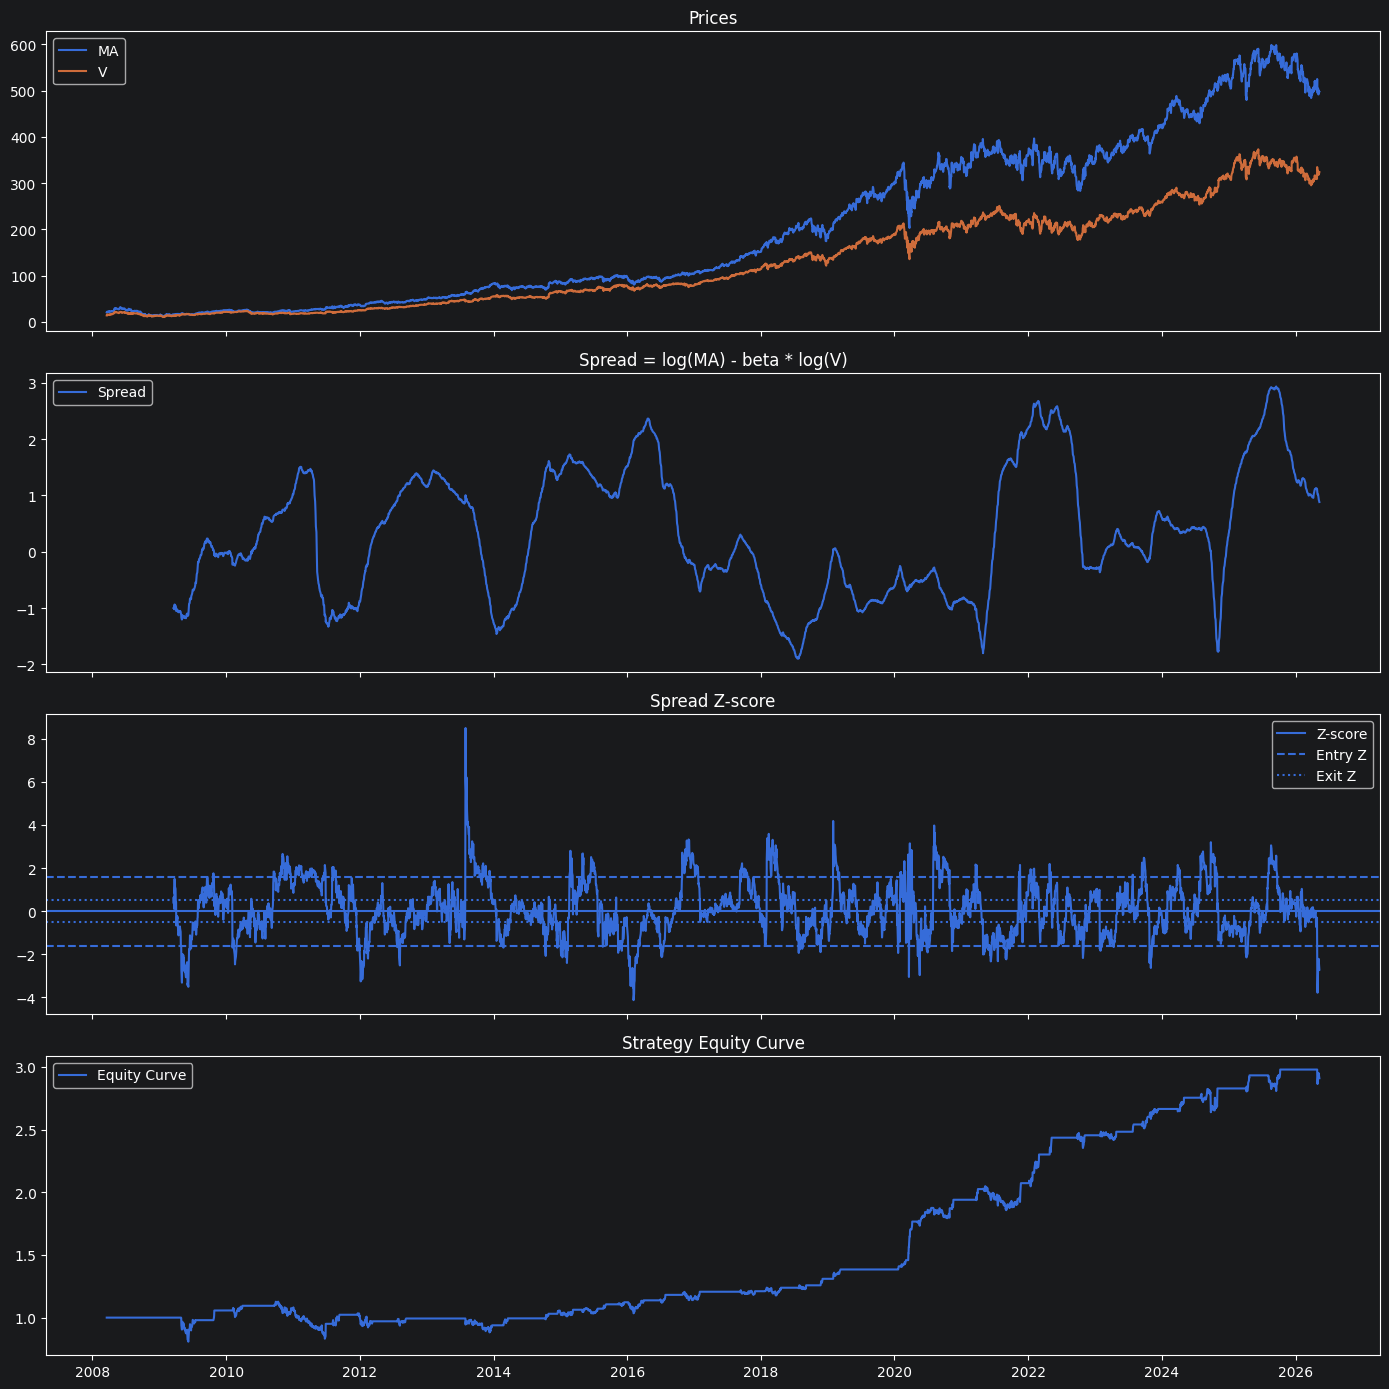

In [20]:
# Plots
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(df["Date"], df["MA"], label="MA")
axes[0].plot(df["Date"], df["V"], label="V")
axes[0].set_title("Prices")
axes[0].legend()

axes[1].plot(df["Date"], df["spread"], label="Spread")
axes[1].set_title("Spread = log(MA) - beta * log(V)")
axes[1].legend()

axes[2].plot(df["Date"], df["zscore"], label="Z-score")
axes[2].axhline(entry_z, linestyle="--", label="Entry Z")
axes[2].axhline(-entry_z, linestyle="--")
axes[2].axhline(exit_z, linestyle=":", label="Exit Z")
axes[2].axhline(-exit_z, linestyle=":")
axes[2].axhline(0, linestyle="-")
axes[2].set_title("Spread Z-score")
axes[2].legend()

axes[3].plot(df["Date"], df["equity_curve"], label="Equity Curve")
axes[3].set_title("Strategy Equity Curve")
axes[3].legend()

plt.tight_layout()
plt.show()
